In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('popular-languages.csv')
df.head()

,language,: average_salary
0,Python,"$114,383"
1,Java,"$101,013"
2,R,"$92,037"
3,Javascript,"$110,981"
4,Swift,"$130,801"


In [14]:
df.value_counts()

language    : average_salary
C#          $88,726             1
C++         $113,865            1
Go          $94,082             1
Java        $101,013            1
Javascript  $110,981            1
PHP         $84,727             1
Python      $114,383            1
R           $92,037             1
SQL         $84,793             1
Swift       $130,801            1
Name: count, dtype: int64

In [21]:
# Remove $ and , then convert to numeric
df['average_salary'] = df['average_salary'].str.replace('[$,]', '', regex=True).astype(float)


AttributeError: Can only use .str accessor with string values!

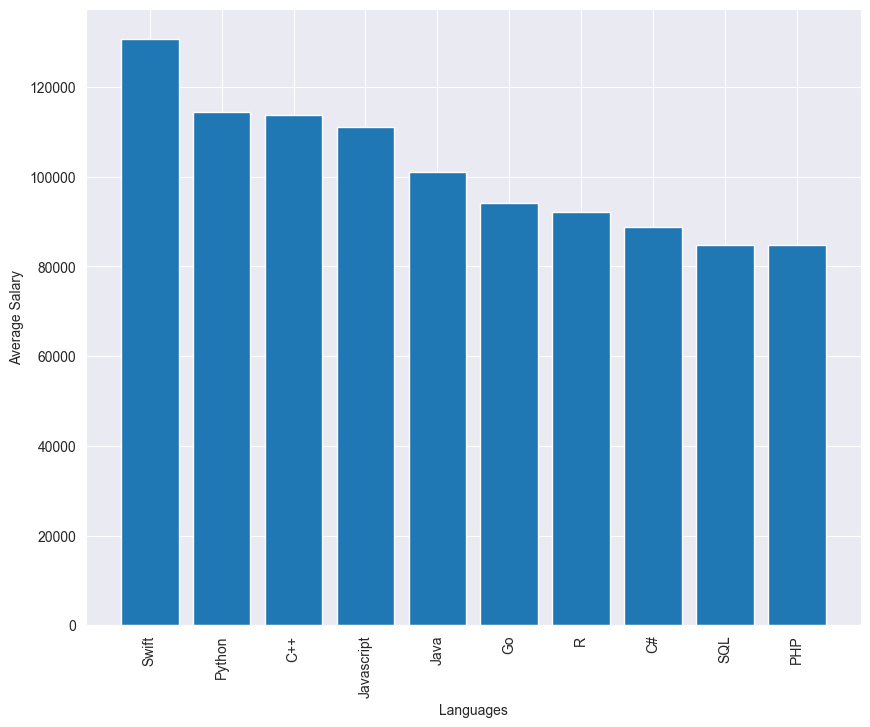

In [22]:
top_languages = df.groupby('language')['average_salary'].mean().nlargest(10).reset_index()
plt.figure(figsize=(10, 8))
plt.bar(top_languages['language'], top_languages['average_salary'])
plt.xticks(rotation=90)
plt.xlabel("Languages")
plt.ylabel("Average Salary")
plt.show()

In [23]:
import sqlite3

In [26]:
query = 'select name from sqlite_master where type="table"'
conn = sqlite3.connect('survey-results-public.sqlite')
c = conn.cursor()
c.execute(query)
table = c.fetchall() 
conn.close()
print(table)

[('main',)]


In [33]:
query = 'SELECT * FROM main'
conn = sqlite3.connect('survey-results-public.sqlite')
df = pd.read_sql_query('SELECT * FROM main', conn)
conn.close()
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,None,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,None,None,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",None,Apples,None,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",None,Apples,None,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [34]:
print(df.columns) 

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='object', length=114)
